# Module 1 · From a "Recipe Table" to Property Prediction: Classical Machine Learning

**Setting.** ~1,800 acidic-OER electrocatalyst records mined from the literature. Each row is one *composition + synthesis + testing* recipe; the label is the overpotential η₁₀ (lower is better). We train models to predict η₁₀ from the recipe, and find which factors matter most.

**Why it's worth learning.** This is a generic *composition → property* template. Swap in your own system (alloys, perovskites, electrolytes…) and the whole pipeline carries over.

**Pipeline.** read table → feature engineering (element → physical properties) → modeling (linear → tree → ensemble → MLP → committee) → SHAP interpretation → optional unsupervised visualization.

## 0. Setup

In [ ]:
# Colab setup: fetch the data and enter this module's folder. No-op when run locally.
import os, sys
REPO = "https://github.com/ruiding-uchicago/NRT_Training_Materials.git"
MODULE = "module_1_tabular_ML"
if "google.colab" in sys.modules and not os.path.isdir("data"):
    root = "/content/NRT_Training_Materials"
    if not os.path.isdir(root):
        os.system("git clone --depth 1 " + REPO + " " + root)
    os.chdir(root + "/" + MODULE)
print("working dir:", os.getcwd(), "| data present:", os.path.isdir("data"))

In [1]:
import sys, subprocess, os
# On Google Colab, auto-install the two packages it doesn't ship with (no-op locally)
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "shap", "xgboost"])
os.makedirs("figures", exist_ok=True)        # so savefig() works on a fresh machine / Colab
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, re
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110
RND = 42

## 1. Read the table

The first gotcha is real: this file is GBK-encoded, not UTF-8 (common for data exported from Excel or a Chinese Windows machine). A plain `read_csv` throws `UnicodeDecodeError`, so we pass the `encoding` explicitly.

In [2]:
DATA_PATH = "OER_activity.csv"          # Colab: upload the file, then point this to it
df = pd.read_csv(DATA_PATH, encoding="gbk")   # note: GBK, not UTF-8
print("shape:", df.shape)
df.head(3)

shape: (1847, 39)


,DOI,Country,Facility,Journal,Impact Factor,Published Date,Cited Times,Number of days until 01/20/2023,Average cited times per day,Metal_Dopant_1,...,Annealing Atomosphere Reductive (0/1),Post-processing Acid Wash etc. (0/1),Catalyst Loading (mg cm -2),Support Material Loading (mg cm -2),Support is not Carbon (0/1),Electrode Type_Glassy Carbon/Carbon Paper or Ti Mesh (0/1),LSV Scanning Speed (mV s-1),Electrolyte Proton Concentration (M),Electrolyte O2 Saturated (0/1),Overpotential (mV @10 mA cm-2)
0,10.1016/j.jallcom.2021.162113,Peoples R China,Qufu Normal Univ,JOURNAL OF ALLOYS AND COMPOUNDS,6.371,10/21/2021,4,456,0.008772,Cu,...,0,0,0.704,0.0,0,0,1.0,1.0,1,216
1,10.1016/j.jallcom.2021.162113,Peoples R China,Qufu Normal Univ,JOURNAL OF ALLOYS AND COMPOUNDS,6.371,10/21/2021,4,456,0.008772,Cu,...,0,0,0.704,0.0,0,0,1.0,1.0,1,201
2,10.1016/j.jallcom.2021.162113,Peoples R China,Qufu Normal Univ,JOURNAL OF ALLOYS AND COMPOUNDS,6.371,10/21/2021,4,456,0.008772,Cu,...,0,0,0.704,0.0,0,0,1.0,1.0,1,245


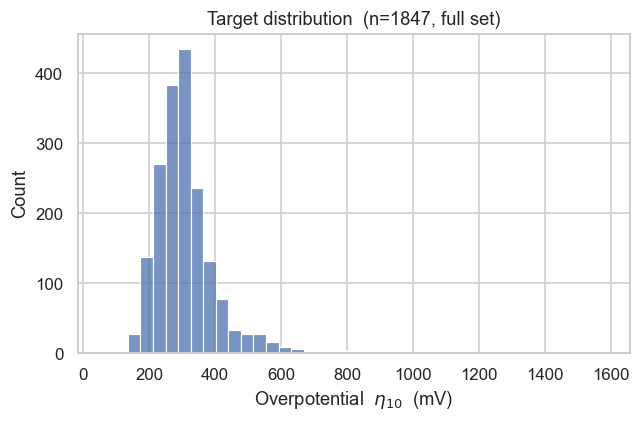

count    1847.0
mean      311.3
std       104.6
min        60.0
25%       252.0
50%       295.0
75%       341.0
max      1580.0
Name: Overpotential (mV @10 mA cm-2), dtype: float64

In [3]:
TARGET = "Overpotential (mV @10 mA cm-2)"
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df[TARGET], bins=40, color="#4C72B0", ax=ax)
ax.set(xlabel=r"Overpotential  $\eta_{10}$  (mV)", ylabel="Count",
       title=f"Target distribution  (n={len(df)}, full set)")
fig.tight_layout(); fig.savefig("figures/01_target_hist.png", dpi=150); plt.show()
df[TARGET].describe().round(1)

The distribution is right-skewed, with a few abnormally high samples. Rather than cutting by value, the paper keeps a high-quality subset chosen by bibliometric quality. This is a handy trick in literature-mined modeling: use citation and journal metadata as a proxy for data quality.

Keep a record if it satisfies any of: Impact Factor ≥ 10, avg. citations/day ≥ 0.025, or published within 365 days of 2023-01-20. We model on this subset (1358 rows) to align with the paper.

In [4]:
hq = ((df["Impact Factor"] >= 10) |
      (df["Average cited times per day"] >= 0.025) |
      (df["Number of days until 01/20/2023"] <= 365))
n0 = len(df); df = df[hq].reset_index(drop=True)
print(f"High-quality subset: {n0} -> {len(df)} rows (bibliometric filter)")

High-quality subset: 1847 -> 1358 rows (bibliometric filter)


## 2. Feature engineering: turning elements into numbers

Models only eat numbers, but the metals in a recipe are symbols (`Fe`, `Ru`, …). Naive one-hot encoding throws away all chemistry. The standard materials-ML move is to replace each element with a vector of its physical properties, so chemically similar elements sit close in feature space.

Each element gets 8 tabulated atomic properties:
> relative atomic mass · atomic number · period · group · ionization energy (eV) · electronegativity (Pauling) · # d-electrons · atomic radius (pm)

A recipe has 4 metal slots, so 4 × 8 = 32 element features. The full 54-column table has four groups:

1. **Element identity** (32): the 8 properties above for each of the 4 metal slots.
2. **Composition** (4): the precursor proportion of each metal.
3. **Synthesis** (12): hydrothermal temperature, time, stirring, strong/weak reductant, and solid-vs-liquid mixing; annealing temperature, time, stirring, inert atmosphere, reductive atmosphere, and acid-wash post-processing.
4. **Electrode and testing** (6): catalyst loading, support loading, support-is-not-carbon, electrode type, LSV scan speed, and electrolyte proton concentration.

(The element table is OER-metal-centric; for other chemistries pull properties from `pymatgen` or `mendeleev`.)

In [5]:
# element -> [rel. atomic mass, atomic number, period, group, ionization energy, electronegativity, # d-electrons, atomic radius]
PROPS = ["Relative Atomic Mass","Atomic Number","Period","Group",
         "Ionization Potential","Electronegativity","Number of d electrons","Atomic Radius"]
element_information = {
"None":[0,0,0,0,0,0,0,0], "none":[0,0,0,0,0,0,0,0],
"Li":[6.941,3,2,1,5.37,0.98,0,145], "B":[10.811,5,2,13,8.33,2.04,0,98],
"C":[12.0107,6,2,14,11.22,2.56,0,77], "N":[14.0067,7,2,15,14.48,3.04,0,92],
"F":[18.9984,9,2,17,18.6,3.98,0,73], "Na":[22.9897,11,3,1,5.12,0.93,0,190],
"Mg":[24.3050,12,3,2,7.61,1.31,0,160], "Al":[26.9815,13,3,13,5.95,1.61,0,143],
"Si":[28.0855,14,3,14,8.12,1.9,0,132], "P":[30.9737,15,3,15,10.3,2.19,0,128],
"S":[32.065,16,3,16,10.31,2.58,0,127], "Cl":[35.453,17,3,17,12.96,3.16,0,99],
"K":[39.0983,19,4,1,4.32,0.82,0,235], "Ca":[40.078,20,4,2,6.09,1.0,0,197],
"Sc":[44.956,21,4,3,6.57,1.36,1,162], "Ti":[47.867,22,4,4,6.81,1.54,2,147],
"V":[50.942,23,4,5,6.76,1.63,3,134], "Cr":[51.996,24,4,6,6.74,1.66,4,130],
"Mn":[54.938,25,4,7,7.4,1.56,5,127], "Fe":[55.845,26,4,8,7.83,1.83,6,126],
"Co":[58.933,27,4,9,7.81,1.88,7,125], "Ni":[58.6934,28,4,10,7.61,1.91,8,124],
"Cu":[63.546,29,4,11,7.69,1.9,10,128], "Zn":[65.38,30,4,12,9.35,1.65,10,138],
"Ga":[69.723,31,4,13,5.97,1.81,10,141], "Se":[78.96,34,4,16,9.5,2.55,10,140],
"Br":[79.904,35,4,17,11.8,2.96,10,115], "Sr":[87.62,38,5,2,5.67,0.95,10,215],
"Y":[88.905,39,5,3,6.5,1.22,1,178], "Zr":[91.224,40,5,4,6.0,1.33,2,160],
"Nb":[92.906,41,5,5,6.76,1.6,4,146], "Mo":[95.94,42,5,6,7.35,2.16,5,139],
"Tc":[98.906,43,5,7,7.28,1.9,5,136], "Ru":[101.07,44,5,8,7.5,2.2,7,134],
"Rh":[102.905,45,5,9,7.7,2.28,8,134], "Pd":[106.42,46,5,10,8.3,2.2,10,137],
"Ag":[107.868,47,5,11,7.54,1.93,10,144], "Cd":[112.411,48,5,12,8.95,1.69,10,154],
"In":[114.818,49,5,13,8.95,1.78,10,166], "Sn":[118.71,50,5,14,7.37,1.96,10,162],
"Sb":[121.760,51,5,15,8.35,2.05,10,159], "Te":[127.6,52,5,16,9.0096,2.1,10,160],
"Ba":[137.327,56,6,2,5.19,0.89,10,222], "La":[138.905,57,6,3,5.5,1.1,1,187],
"Ce":[140.116,58,6,3,6.91,1.12,1,181], "Pr":[140.904,59,6,3,5.76,1.13,10,182],
"Nd":[144.242,60,6,3,6.31,1.14,10,182], "Sm":[150.36,62,6,3,6.55,1.1,10,181],
"Eu":[151.964,63,6,3,5.67,1.2,10,199], "Gd":[157.25,64,6,3,6.65,1.2,1,179],
"Tb":[158.925,65,6,3,6.74,1.2,10,180], "Ho":[164.93,67,6,3,6.022,1.23,10,179],
"Er":[167.529,68,6,3,6.108,1.23,10,178], "Tm":[168.934,69,6,3,6.184,1.25,10,177],
"Lu":[174.967,71,6,3,5.4259,1.27,1,175], "Ta":[180.947,73,6,5,7.89,1.5,3,149],
"W":[183.84,74,6,6,7.98,2.36,4,141], "Os":[190.23,76,6,8,8.7,2.2,6,135],
"Ir":[192.217,77,6,9,9.1,2.2,7,136], "Pt":[195.084,78,6,10,8.9,2.28,9,139],
"Au":[196.966,79,6,11,9.19,2.54,10,144], "Pb":[207.2,82,6,14,7.38,2.33,10,175],
"Bi":[208.98,83,6,15,7.25,2.02,10,170],
}
print("elements covered:", len([k for k in element_information if k not in ('None','none')]))

elements covered: 63


In [6]:
ELEMENT_COLS = ["Metal_Dopant_1","Metal_Dopant_2","Metal_Dopant_3","Metal_Dopant_4"]
# Drop everything that is NOT an element column, a numeric experimental condition, or the target:
# bibliometric metadata + IDs + two near-constant/irrelevant columns. (Keeping these would leak or add noise.)
META_DROP = ["DOI","Country","Facility","Journal","Impact Factor","Published Date",
    "Cited Times","Number of days until 01/20/2023","Average cited times per day",
    "Annealing Temerature Rising Rate (Celcius Degree min-1)","Electrolyte O2 Saturated (0/1)","Sample Name"]

def featurize(frame):
    frame = frame.copy()
    # coverage check: any element not in the table falls back to a zero vector (with a warning)
    seen = pd.unique(frame[ELEMENT_COLS].fillna("None").astype(str).values.ravel())
    missing = [e for e in seen if e not in element_information]
    if missing: print("WARNING: elements not in table (set to 0):", missing)
    blocks = []
    for slot, col in enumerate(ELEMENT_COLS, start=1):
        mapped = frame[col].fillna("None").astype(str).map(
            lambda e: element_information.get(e, element_information["None"]))
        blocks.append(pd.DataFrame(mapped.tolist(),
            columns=[f"M{slot}:{p}" for p in PROPS], index=frame.index))  # M1..M4 = the four metal slots
    X_elem = pd.concat(blocks, axis=1)
    cond_cols = [c for c in frame.columns if c not in META_DROP + ELEMENT_COLS + [TARGET]]
    X_cond = frame[cond_cols].apply(pd.to_numeric, errors="coerce")
    X = pd.concat([X_elem, X_cond], axis=1).fillna(0.0)
    X.columns = [re.sub(r"[\[\]<>]", "", str(c)).strip() for c in X.columns]  # XGBoost-friendly names
    y = frame[TARGET].astype(float)
    return X, y

X, y = featurize(df)
print("feature matrix:", X.shape, "(32 element props + 4 proportions + 18 conditions = 54 features)")
print("non-element features:", [c for c in X.columns if not c.startswith(("M1:", "M2:", "M3:", "M4:"))])
X.head(3)

feature matrix: (1358, 54) (32 element props + 4 proportions + 18 conditions = 54 features)
non-element features: ['Metal_Dopant_1 Proportion in Precursor', 'Metal_Dopant_2 Proportion in Precursor', 'Metal_Dopant_3 Proportion in Precursor', 'Metal_Dopant_4 Proportion in Precursor', 'Hydrothermal Temperature (Celcius degree)', 'Hydrothermal Time (min)', 'Hydrothermal Still/Strring (0/1)', 'Hydrothermal Strong Reductant in Liquid (0/1)', 'Hydrothermal Weak Reductant in Liquid (0/1)', 'Mixed in Solid or Liquid (0/1)', 'Annealing Temperature (Celcius Degree)', 'Annealing Time (min)', 'Annealing Still/Strring (0/1)', 'Annealing Atomosphere Inert (0/1)', 'Annealing Atomosphere Reductive (0/1)', 'Post-processing Acid Wash etc. (0/1)', 'Catalyst Loading (mg cm -2)', 'Support Material Loading (mg cm -2)', 'Support is not Carbon (0/1)', 'Electrode Type_Glassy Carbon/Carbon Paper or Ti Mesh (0/1)', 'LSV Scanning Speed (mV s-1)', 'Electrolyte Proton Concentration (M)']


,M1:Relative Atomic Mass,M1:Atomic Number,M1:Period,M1:Group,M1:Ionization Potential,M1:Electronegativity,M1:Number of d electrons,M1:Atomic Radius,M2:Relative Atomic Mass,M2:Atomic Number,...,Annealing Still/Strring (0/1),Annealing Atomosphere Inert (0/1),Annealing Atomosphere Reductive (0/1),Post-processing Acid Wash etc. (0/1),Catalyst Loading (mg cm -2),Support Material Loading (mg cm -2),Support is not Carbon (0/1),Electrode Type_Glassy Carbon/Carbon Paper or Ti Mesh (0/1),LSV Scanning Speed (mV s-1),Electrolyte Proton Concentration (M)
0,58.933,27,4,9,7.81,1.88,7,125,0.000,0,...,0,0,0,0,0.9020,0.1980,0,1,1.0,1.0
1,58.933,27,4,9,7.81,1.88,7,125,55.845,26,...,0,0,0,0,0.8877,0.2123,0,1,1.0,1.0
2,106.420,46,5,10,8.30,2.20,10,137,192.217,77,...,0,0,0,0,0.0680,0.2720,0,0,10.0,0.1


## 3. Modeling: from simple to strong

Split into train/test (90/10 here, matching the paper), and judge regression with three rulers:
- **MAE** (mean absolute error, mV): average miss; lower is better.
- **RMSE**: penalizes big misses more heavily.
- **R²**: fraction of variance explained; 1 is perfect, 0 is no better than predicting the mean.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# train/test split matching the paper: 90/10, fixed seed 6866
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.1, random_state=6866)
results = {}
def evaluate(name, model):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    results[name] = dict(model=model, pred=pred, MAE=mae, RMSE=rmse, R2=r2)
    print(f"{name:14s}  MAE={mae:6.1f}   RMSE={rmse:6.1f}   R2={r2:6.3f}")
    return model

**① Linear regression.** The simplest baseline: it sets a floor that every fancier model should beat.

In [8]:
from sklearn.linear_model import LinearRegression
evaluate("Linear", LinearRegression());

Linear          MAE=  62.7   RMSE=  83.2   R2= 0.192


**② Decision tree.** Captures nonlinearity, but a single tree overfits easily: great on train, poor on test.

In [9]:
from sklearn.tree import DecisionTreeRegressor
m = evaluate("DecisionTree", DecisionTreeRegressor(max_depth=8, random_state=RND))
print(f"   train R2={r2_score(y_tr, m.predict(X_tr)):.3f}  vs  test R2={results['DecisionTree']['R2']:.3f}  <- gap = overfitting")

DecisionTree    MAE=  40.1   RMSE=  59.2   R2= 0.591
   train R2=0.848  vs  test R2=0.591  <- gap = overfitting


> **Try it.** Re-run the tree below at `max_depth=3`, then `20`. Predict first: which way does the train/test gap move? The sweep makes it concrete; that gap is overfitting.

In [10]:
for d in [3, 8, 20]:
    mt = DecisionTreeRegressor(max_depth=d, random_state=RND).fit(X_tr, y_tr)
    tr, te = r2_score(y_tr, mt.predict(X_tr)), r2_score(y_te, mt.predict(X_te))
    print(f"max_depth={d:2d}:  train R2={tr:.3f}   test R2={te:.3f}   gap={tr-te:.3f}")

max_depth= 3:  train R2=0.397   test R2=0.433   gap=-0.037
max_depth= 8:  train R2=0.848   test R2=0.591   gap=0.257
max_depth=20:  train R2=0.993   test R2=0.433   gap=0.561


**③ Ensembles: Random Forest and XGBoost.** They combine many trees, and are the most reliable baseline on tabular data.

In [11]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
evaluate("RandomForest", RandomForestRegressor(n_estimators=400, n_jobs=-1, random_state=RND))
evaluate("XGBoost", XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5,
         subsample=0.8, colsample_bytree=0.8, random_state=RND, n_jobs=-1));

RandomForest    MAE=  29.0   RMSE=  40.7   R2= 0.807


XGBoost         MAE=  27.7   RMSE=  37.2   R2= 0.838


**④ MLP (multilayer perceptron / neural net): your first neural network**

Neural nets are sensitive to feature scale: atomic mass is in the hundreds while electronegativity is around 1, so without scaling the large-magnitude features dominate training. The standard fix is StandardScaler + MLP wrapped in a Pipeline, with the scaler fit on the training set only to avoid leakage.

On a dataset this small (~1.2k rows) the MLP usually loses to the tree ensembles: neural nets are data-hungry and have no built-in handling of mixed-scale tabular features. It is here as the bridge to deep learning (Module 2), and because its disagreement with the trees feeds the committee below.

In [12]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
mlp = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(256, 128), activation="relu", alpha=3e-4,
                 learning_rate_init=8e-4, max_iter=1500, early_stopping=True,
                 n_iter_no_change=30, random_state=RND))
evaluate("MLP", mlp);

MLP             MAE=  51.7   RMSE=  68.4   R2= 0.454


**⑤ Committee ensemble: the finale, and the core of the paper's active learning**

Averaging several different models gives a prediction that doesn't hinge on any single one. The more useful part is that the spread between models (their standard deviation) estimates uncertainty: the paper picks its next experiments exactly where the committee disagrees most.

> **Caution.** A plain average does not guarantee beating the best single model; here the weaker MLP drags the mean down. The committee earns its keep through reliability plus an uncertainty estimate, and that uncertainty is what active learning needs.

To actually run active learning, score your unlabeled candidate recipes and pick the top-k by committee disagreement (`ens_std`) as the next experiments to measure.

In [13]:
members = ["RandomForest", "XGBoost", "MLP"]
P = np.column_stack([results[m]["pred"] for m in members])
ens_pred = P.mean(axis=1)
ens_std  = P.std(axis=1)          # committee disagreement = uncertainty signal
mae, rmse, r2 = (mean_absolute_error(y_te, ens_pred),
                 np.sqrt(mean_squared_error(y_te, ens_pred)), r2_score(y_te, ens_pred))
results["Committee"] = dict(model=None, pred=ens_pred, MAE=mae, RMSE=rmse, R2=r2)
print(f"{'Committee':14s}  MAE={mae:6.1f}   RMSE={rmse:6.1f}   R2={r2:6.3f}")
print(f"committee disagreement (mV): mean {ens_std.mean():.1f}, max {ens_std.max():.1f}  <- large = least confident = best to sample next")

Committee       MAE=  31.6   RMSE=  41.2   R2= 0.802
committee disagreement (mV): mean 20.4, max 202.2  <- large = least confident = best to sample next


### Head-to-head and fit quality

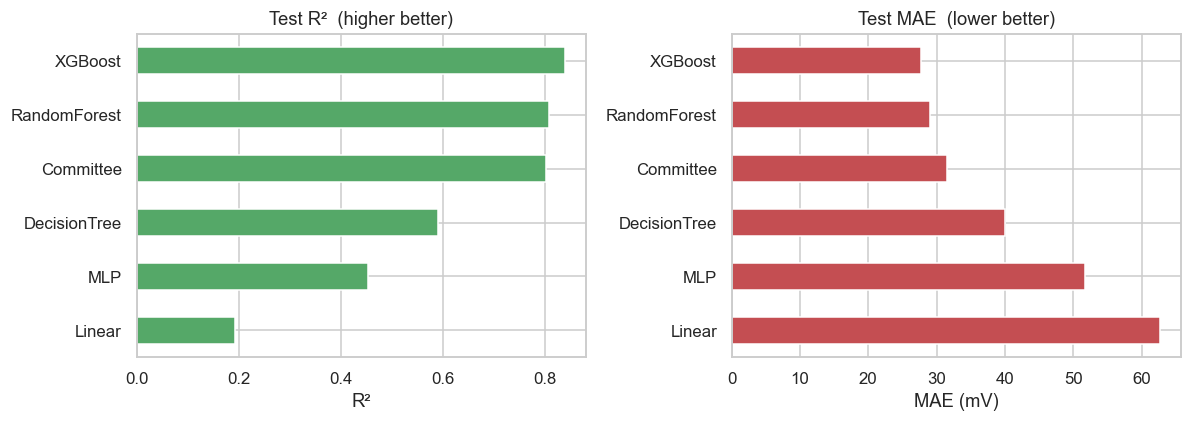

In [14]:
comp = pd.DataFrame({k: {"R2": v["R2"], "MAE": v["MAE"]} for k, v in results.items()}).T
order = comp["R2"].sort_values().index
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
comp.loc[order, "R2"].plot.barh(ax=ax[0], color="#55A868")
ax[0].set(title="Test R²  (higher better)", xlabel="R²")
comp.loc[order, "MAE"].plot.barh(ax=ax[1], color="#C44E52")
ax[1].set(title="Test MAE  (lower better)", xlabel="MAE (mV)")
fig.tight_layout(); fig.savefig("figures/02_model_comparison.png", dpi=150); plt.show()

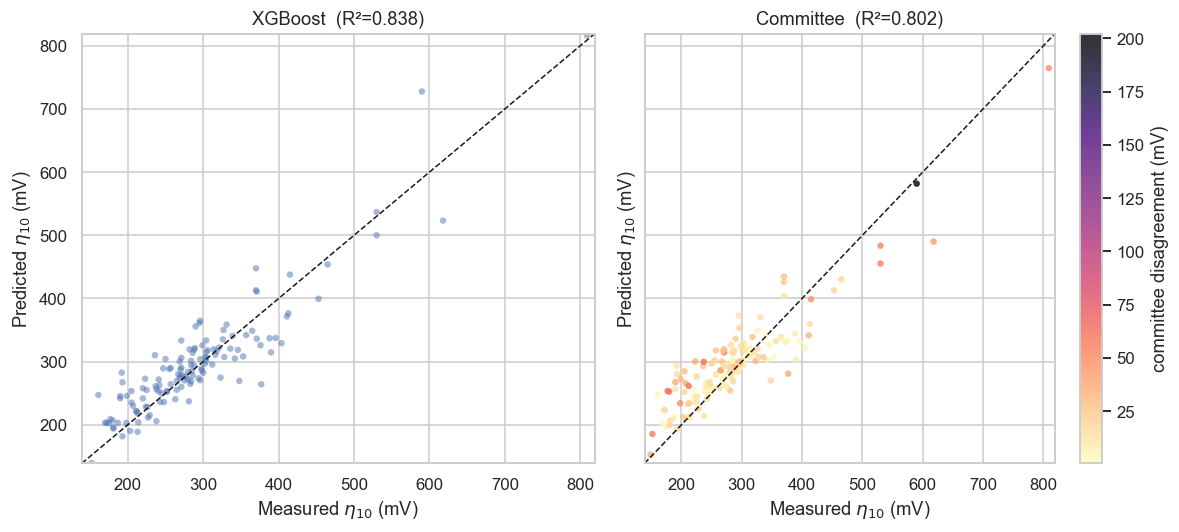

In [15]:
# predicted vs measured (parity plot): closer to the diagonal = more accurate
fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
lims = [y_te.min() - 10, y_te.max() + 10]
ax[0].scatter(y_te, results["XGBoost"]["pred"], s=18, alpha=0.5, color="#4C72B0", edgecolor="none")
ax[0].set(title=f"XGBoost  (R²={results['XGBoost']['R2']:.3f})")
sc = ax[1].scatter(y_te, ens_pred, c=ens_std, s=18, alpha=0.8, cmap="magma_r", edgecolor="none")
ax[1].set(title=f"Committee  (R²={results['Committee']['R2']:.3f})")
fig.colorbar(sc, ax=ax[1], label="committee disagreement (mV)")
for a in ax:
    a.plot(lims, lims, "k--", lw=1); a.set(xlim=lims, ylim=lims,
        xlabel=r"Measured $\eta_{10}$ (mV)", ylabel=r"Predicted $\eta_{10}$ (mV)")
fig.tight_layout(); fig.savefig("figures/03_parity.png", dpi=150); plt.show()

> **Try it.** Change which models vote in the committee below. Does folding in a weak model help or hurt? Tie your answer to the caution above.

In [16]:
for combo in [["RandomForest","XGBoost"], ["RandomForest","XGBoost","MLP"],
              ["RandomForest","XGBoost","MLP","Linear","DecisionTree"]]:
    pp = np.column_stack([results[m]["pred"] for m in combo]).mean(1)
    print(f"committee = {'+'.join(combo):44s} R2={r2_score(y_te, pp):.3f}")

committee = RandomForest+XGBoost                         R2=0.829
committee = RandomForest+XGBoost+MLP                     R2=0.802
committee = RandomForest+XGBoost+MLP+Linear+DecisionTree R2=0.764


### Committee disagreement as a reliability signal

The paper's active-learning loop rests on one bet: where the committee disagrees most, the prediction is least reliable, so those recipes are the ones worth testing next. We can't run the real loop here (in the paper, each round meant synthesizing and measuring real catalysts in the lab), but we can check the bet on our held-out data.

In [17]:
err = np.abs(results["Committee"]["pred"] - y_te.values)
cut = np.median(ens_std)
lo, hi = err[ens_std <= cut].mean(), err[ens_std > cut].mean()
print(f"low-disagreement half : MAE = {lo:.1f} mV")
print(f"high-disagreement half: MAE = {hi:.1f} mV   ({hi/lo:.1f}x worse)")

low-disagreement half : MAE = 26.0 mV
high-disagreement half: MAE = 37.1 mV   (1.4x worse)


The high-disagreement half really is harder to predict, so committee disagreement is a usable "the model doesn't know here" signal, and it needs no labels to compute.

**How the real loop closes (not shown here).** A genetic algorithm searches the recipe space for points of highest disagreement (explore) or lowest predicted overpotential (exploit). Those recipes are then synthesized and tested in the lab, the new data is added, and the committee is retrained. The notebook produces the signal; the wet lab is the oracle. See `Adaptive_Active Learning Loop&GA Prediction/` in the DASH repo. (A self-contained active-learning / Bayesian-optimization simulation would be a natural Module 3.)

### Use the model: predict a recipe

This is the payoff of a trained model: ask "what if I make this?" without touching a beaker. Edit `metals`, `proportions`, or the conditions and re-run; you get the committee's prediction and its uncertainty.

In [18]:
def predict_recipe(metals, proportions, **conditions):
    row = X_tr.median().copy()                      # start from a 'typical' catalyst, then override
    for i in range(4):
        sym = metals[i] if i < len(metals) else "None"
        for p, val in zip(PROPS, element_information.get(sym, element_information["None"])):
            row[f"M{i+1}:{p}"] = val
        row[f"Metal_Dopant_{i+1} Proportion in Precursor"] = proportions[i] if i < len(proportions) else 0.0
    for k, v in conditions.items():
        if k in row.index: row[k] = v
    xq = row.to_frame().T
    p = {n: float(results[n]["model"].predict(xq)[0]) for n in ["RandomForest", "XGBoost", "MLP"]}
    vals = np.array(list(p.values()))
    return vals.mean(), vals.std(), p

mu, sd, members = predict_recipe(["Ru", "Ni"], [80, 20],
                                 **{"Annealing Temperature (Celcius Degree)": 400})
print(f"Predicted overpotential η10 = {mu:.0f} ± {sd:.0f} mV   (committee mean ± disagreement)")
for n, v in members.items(): print(f"   {n:13s} {v:.0f} mV")

Predicted overpotential η10 = 274 ± 17 mV   (committee mean ± disagreement)
   RandomForest  284 mV
   XGBoost       289 mV
   MLP           250 mV


## 4. Interpreting predictions with SHAP

High accuracy isn't enough; materials research wants to know which factors drive performance. SHAP splits each prediction into per-feature contributions:
- **bar plot**: average feature-importance ranking (magnitude only, not direction).
- **beeswarm**: each dot is a sample; color is the feature value (high/low), and the x-axis is whether it pushes η₁₀ up (right) or down (left).

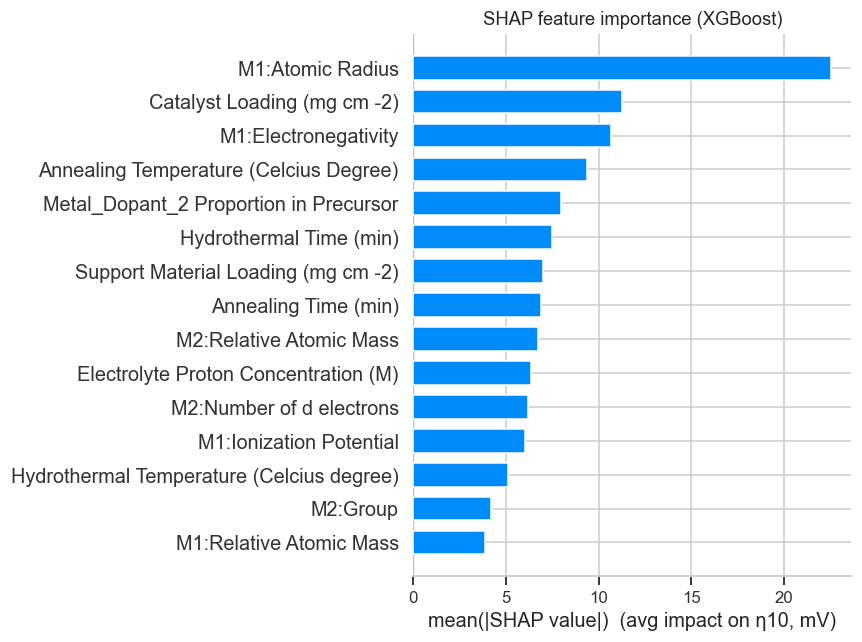

Top-10 features:
M1:Atomic Radius                          22.530001
Catalyst Loading (mg cm -2)               11.280000
M1:Electronegativity                      10.700000
Annealing Temperature (Celcius Degree)     9.360000
Metal_Dopant_2 Proportion in Precursor     8.000000
Hydrothermal Time (min)                    7.490000
Support Material Loading (mg cm -2)        7.020000
Annealing Time (min)                       6.880000
M2:Relative Atomic Mass                    6.750000
Electrolyte Proton Concentration (M)       6.330000


In [19]:
import shap
expl_model = results["XGBoost"]["model"]
Xs = X_te.sample(min(400, len(X_te)), random_state=RND)
sv = shap.TreeExplainer(expl_model).shap_values(Xs)

shap.summary_plot(sv, Xs, plot_type="bar", max_display=15, show=False)
plt.gcf().set_size_inches(8, 6); plt.xlabel("mean(|SHAP value|)  (avg impact on η10, mV)")
plt.title("SHAP feature importance (XGBoost)")
plt.tight_layout(); plt.savefig("figures/04_shap_bar.png", dpi=150, bbox_inches="tight"); plt.show()

imp = pd.Series(np.abs(sv).mean(0), index=Xs.columns).sort_values(ascending=False)
print("Top-10 features:"); print(imp.head(10).round(2).to_string())

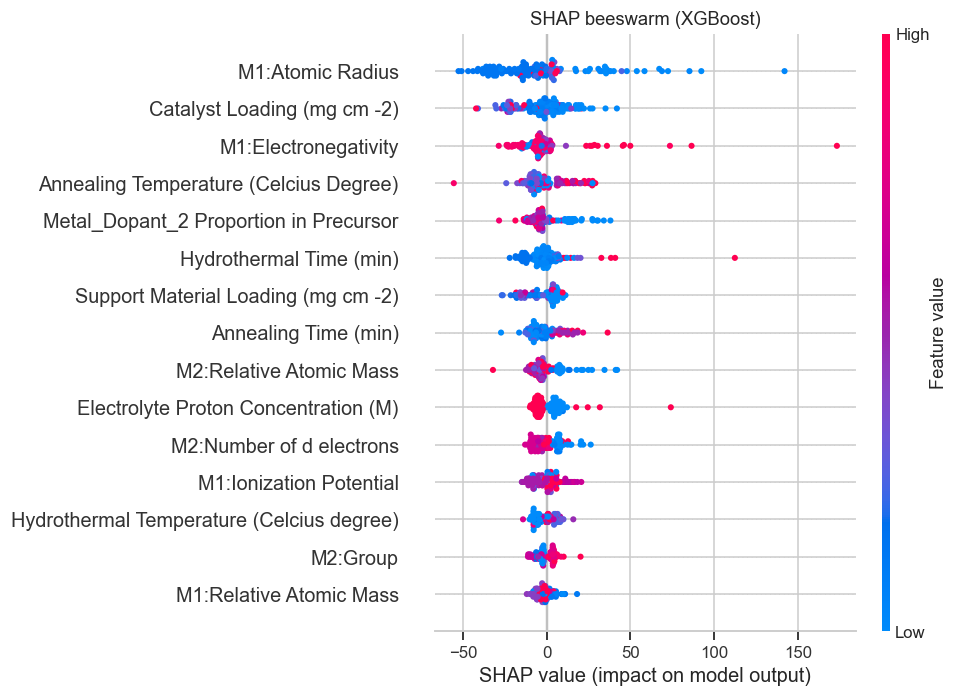

In [20]:
shap.summary_plot(sv, Xs, max_display=15, show=False)
plt.gcf().set_size_inches(9, 6.5)
plt.title("SHAP beeswarm (XGBoost)")
plt.tight_layout(); plt.savefig("figures/05_shap_beeswarm.png", dpi=150, bbox_inches="tight"); plt.show()

**How to read it.** The biggest contributors mix electronic-structure descriptors of the main metal (atomic radius, electronegativity, ionization energy, # d-electrons) with synthesis conditions (annealing temperature, hydrothermal time). That matches the intuition that OER activity is set by intrinsic electronic structure plus processing.

Notice that a testing condition such as Catalyst Loading often ranks near the top. It doesn't change the material itself, yet it strongly affects the measured overpotential. In literature-mined data, testing conditions are strong confounders: watch out for a model that learns the test setup instead of the material. Checking the SHAP ranking is how you catch this.

> **Try it: the confounder cure.** Catalyst Loading and other testing conditions aren't material properties, yet they rank high. Drop them and re-fit: the R² you lose is roughly how much the model leaned on the test setup instead of the material.

In [21]:
test_cond = [c for c in ["Catalyst Loading (mg cm -2)", "Support Material Loading (mg cm -2)",
                         "LSV Scanning Speed (mV s-1)"] if c in X.columns]
keep = [c for c in X.columns if c not in test_cond]
mat = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8,
                   colsample_bytree=0.8, random_state=RND, n_jobs=-1).fit(X_tr[keep], y_tr)
print(f"full model                          R2 = {results['XGBoost']['R2']:.3f}")
print(f"material-only (dropped {len(test_cond)} test cols) R2 = {r2_score(y_te, mat.predict(X_te[keep])):.3f}")

full model                          R2 = 0.838
material-only (dropped 3 test cols) R2 = 0.774


## 5. (Optional) An unsupervised look at the data

Beyond supervised learning, unsupervised methods help you see the data's structure before modeling. Two common ones: the features most correlated with the target, and a 2-D PCA / t-SNE map of the 54-D data.

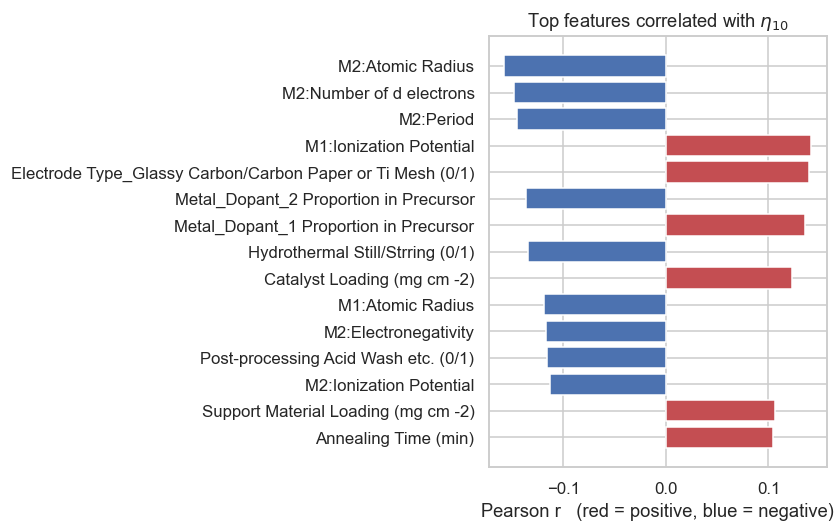

In [22]:
corr = X.assign(**{TARGET: y.values}).corr(numeric_only=True)[TARGET].drop(TARGET)
top = corr.reindex(corr.abs().sort_values(ascending=False).index).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.8, 5))
ax.barh(top.index, top.values, color=np.where(top > 0, "#C44E52", "#4C72B0"))
ax.set_xlabel("Pearson r   (red = positive, blue = negative)")
ax.set_title(r"Top features correlated with $\eta_{10}$")
fig.tight_layout(); fig.savefig("figures/06_corr.png", dpi=150, bbox_inches="tight"); plt.show()

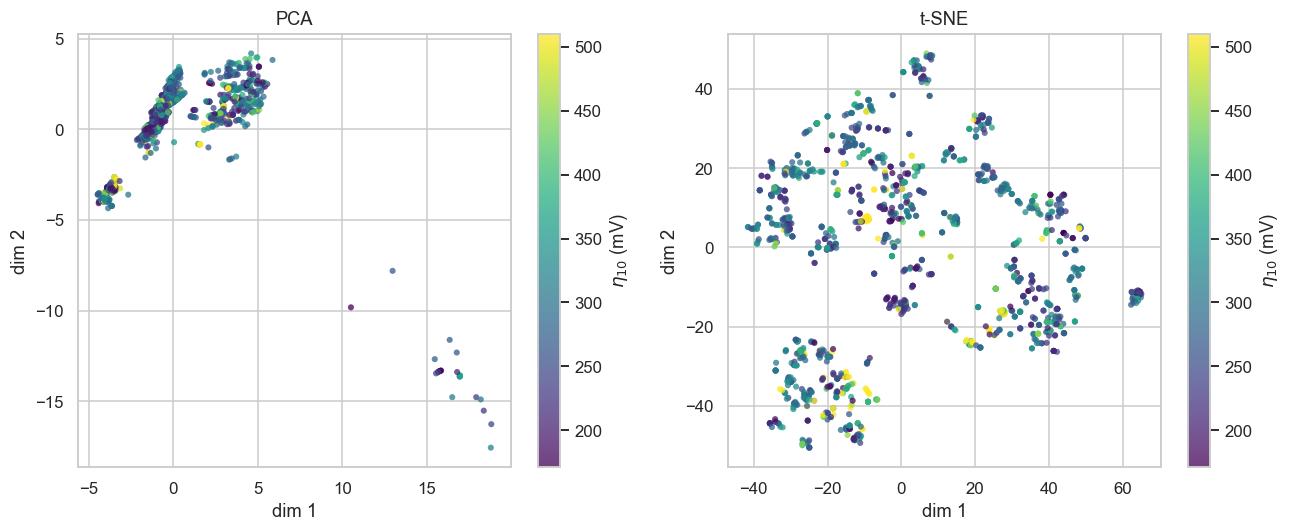

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
# unsupervised viz: no held-out label here, so scaling on all rows is fine (not leakage)
Xz = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=RND).fit_transform(Xz)
tsne = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", random_state=RND).fit_transform(Xz)

vmin, vmax = y.quantile(0.02), y.quantile(0.95)   # clip color scale so a few high-eta outliers don't wash out the bulk
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, emb, name in [(ax[0], pca, "PCA"), (ax[1], tsne, "t-SNE")]:
    sc = a.scatter(emb[:, 0], emb[:, 1], c=y, s=16, cmap="viridis", alpha=0.75, edgecolor="none", vmin=vmin, vmax=vmax)
    a.set(title=name, xlabel="dim 1", ylabel="dim 2")
    fig.colorbar(sc, ax=a, label=r"$\eta_{10}$ (mV)")
fig.tight_layout(); fig.savefig("figures/07_pca_tsne.png", dpi=150); plt.show()

## 6. Wrap-up and reuse on your own data

Takeaways:
1. **Feature engineering beats model choice.** Mapping elements to physical properties (instead of one-hot) is the highest-return step in materials ML.
2. For tabular data, start with tree ensembles (Random Forest, XGBoost) as a strong baseline. Always scale before an MLP. A committee buys you a prediction plus an uncertainty estimate.
3. Always interpret. SHAP shows which features drive a prediction, which is what reviewers will ask for.

To reuse this on your project:
- Swap `DATA_PATH` and `TARGET`. Set `ELEMENT_COLS` to your element columns, and `META_DROP` to everything that is not an element column, a numeric experimental condition, or the target (IDs, bibliometric metadata, and free text all leak or add noise).
- `ELEMENT_COLS` length is free: 2 slots for a binary alloy, 5 for a high-entropy alloy. The "4 slots → 32 features" count above is specific to this dataset.
- The element-to-properties idea in `featurize()` works for any system with elements or molecules.
- Everything else (modeling, SHAP, dimensionality reduction) runs as is.

## Source and citation

This module is a teaching rewrite of the data-mining workflow from:

> R. Ding, J. Liu, K. Hua, X. Wang, X. Zhang, M. Shao, Y. Chen, J. Chen,
> "Leveraging data mining, active learning, and domain adaptation for efficient discovery of advanced oxygen evolution electrocatalysts,"
> *Science Advances* **11**, eadr9038 (2025). doi:[10.1126/sciadv.adr9038](https://www.science.org/doi/full/10.1126/sciadv.adr9038)

- Code and data (DASH repo): https://github.com/ruiding-uchicago/DASH
- Dataset archive (Dryad): doi:10.5061/dryad.nk98sf83g

Released for educational use; please cite the paper above if you build on this material.